In [ ]:
# Now let's all the necessary libraries here 

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns
from mlxtend.plotting import plot_decision_regions

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

import tensorflow as tf
import keras 
import keras_tuner as kt

from keras.callbacks import EarlyStopping
from keras.optimizers import Adam,SGD,RMSprop
from keras.models import Sequential
from keras.layers import Input,Activation
from keras.layers import Dropout,Dense,BatchNormalization

In [31]:
df = pd.read_csv('insurance.csv')

In [32]:
df.shape

(1338, 7)

In [33]:
df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [34]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   str    
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   str    
 5   region    1338 non-null   str    
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), str(3)
memory usage: 73.3 KB


In [35]:
# This is also one of the famous dataset so we just need to map sex and age into binary and make seperate columns for region usng onc 

In [36]:
df['sex'] = df['sex'].map({
                                'female': 0,
                                'male' : 1
})

In [37]:
df['smoker'] = df['smoker'].map({
                                'no': 0,
                                'yes' : 1
})

In [38]:
df = pd.get_dummies(df,columns=['region'],dtype=int) # OneHotEncode using get_dummmies

In [40]:
df.head() # All set

,age,sex,bmi,children,smoker,charges,region_northeast,region_northwest,region_southeast,region_southwest
0,19,0,27.900,0,1,16884.92400,0,0,0,1
1,18,1,33.770,1,0,1725.55230,0,0,1,0
2,28,1,33.000,3,0,4449.46200,0,0,1,0
3,33,1,22.705,0,0,21984.47061,0,1,0,0
4,32,1,28.880,0,0,3866.85520,0,1,0,0


In [46]:
# I also want to see the corr of the values with charges
df.corr()['charges'] # We won't remove the non significant columns here for now ; maybe later during experimenting

age                 0.299008
sex                 0.057292
bmi                 0.198341
children            0.067998
smoker              0.787251
charges             1.000000
region_northeast    0.006349
region_northwest   -0.039905
region_southeast    0.073982
region_southwest   -0.043210
Name: charges, dtype: float64

In [41]:
# Now we will split the data into X,y and then training and testing set for our ann

In [42]:
X,y = df.drop(columns=['charges']),df['charges']

In [44]:
X_train , X_test , y_train , y_test = train_test_split(
                                                            X,y,
                                                            test_size = 0.2,
                                                            random_state = 42
)

In [52]:
# Now we have one last step left that is Normalization which we will do using StandardScaler
scale = StandardScaler()
scale.fit(X_train)

X_train_scalled = scale.transform(X_train)
X_test_scalled = scale.transform(X_test)

In [48]:
# Now we are readly for the model building phase

In [ ]:
# We will be using the linear model for the outpu layer
# Hidden Layer = 2 for now and the Activation will be relu
# No of neurons will be 12 for each layer now

In [56]:
model = Sequential()

model.add(Input(shape=(X.shape[1],)))

model.add(Dense(12))
model.add(Activation('relu'))

model.add(Dense(12))
model.add(Activation('relu'))

model.add(Dense(1))
model.add(Activation('linear'))

model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_1 (Dense)                 │ (None, 12)             │           120 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_1 (Activation)       │ (None, 12)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 12)             │           156 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_2 (Activation)       │ (None, 12)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            13 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_3 (Activation)       │ (None, 1)              │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 289 (1.13 KB)

 Trainable params: 289 (1.13 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# Model compiling 
model.compile(
                optimizer = 'adam',
                loss = 'mean_squared_error', # The loss function to assign
                metrics = ['mae', 'root_mean_squared_error'] # Assign the metrics to evaluate the model perforamces
)

In [59]:
# Model Training
history = model.fit(
            X_train,y_train,
            epochs = 100,
            validation_data = (X_test,y_test),
            batch_size = 32
)

Epoch 1/100


34/34 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - loss: 124703888.0000 - mae: 8895.6006 - root_mean_squared_error: 11167.0898 - val_loss: 128787408.0000 - val_mae: 9151.4912 - val_root_mean_squared_error: 11348.4541
Epoch 2/100
34/34 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 124660296.0000 - mae: 8931.8486 - root_mean_squared_error: 11165.1377 - val_loss: 128724568.0000 - val_mae: 9187.1992 - val_root_mean_squared_error: 11345.6846
Epoch 3/100
34/34 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - loss: 124592464.0000 - mae: 8900.5938 - root_mean_squared_error: 11162.0996 - val_loss: 128643288.0000 - val_mae: 9151.0205 - val_root_mean_squared_error: 11342.1025
Epoch 4/100
34/34 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 124512160.0000 - mae: 8909.9502 - root_mean_squared_error: 11158.5020 - val_loss: 128573224.0000 - val_mae: 9157.2715 - val_root_mean_squared_error: 11339.0137
Epoch 5/100
34/34 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 124439424.0000 - mae: 8911.1611 - root_mean_squared_error: 11155.2422 - 

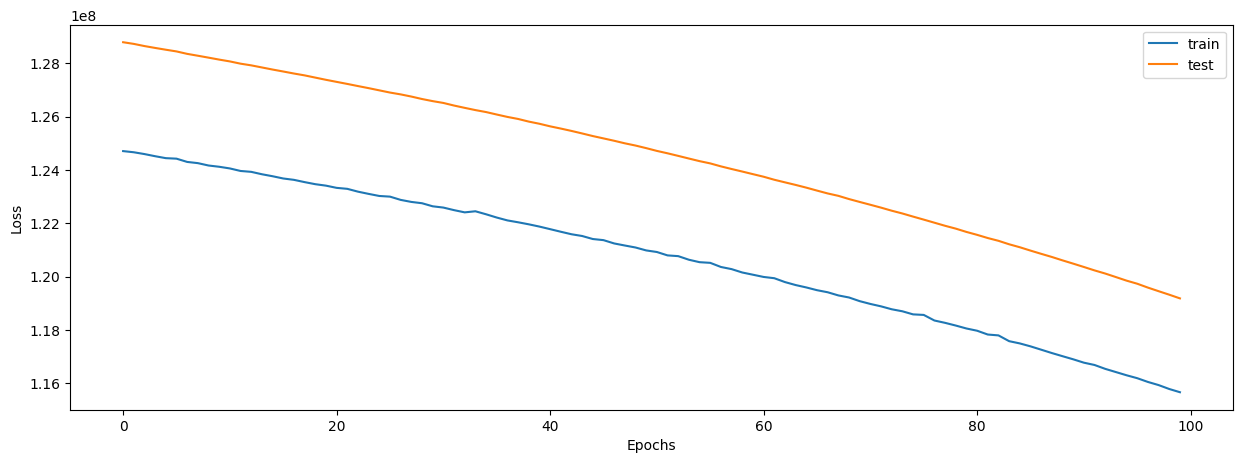

In [60]:
# Plot the model performance 
plt.figure(figsize=(15,5))
plt.plot(history.history['loss'], label='train')
plt.plot(history.history['val_loss'], label='test')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

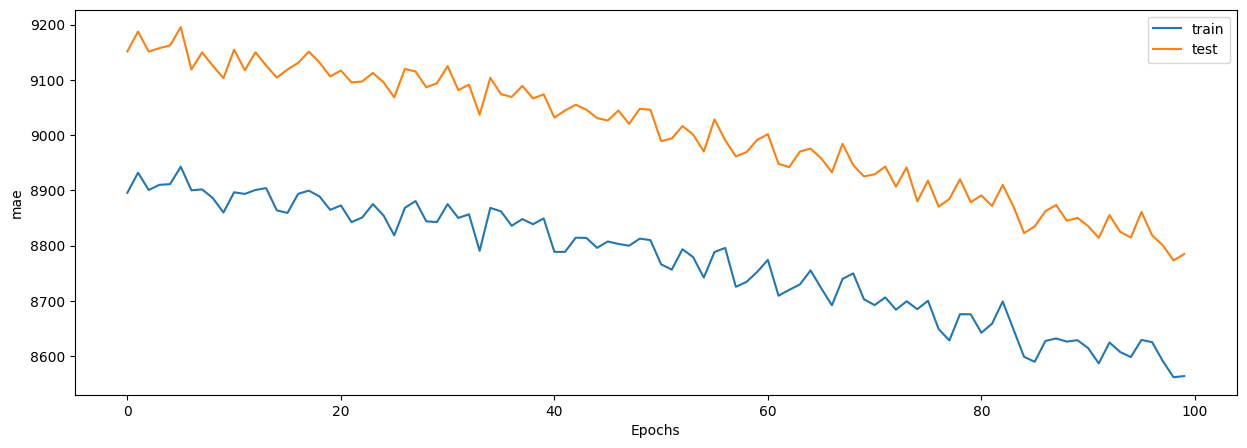

In [63]:
# Plot the model performance 
plt.figure(figsize=(15,5))
plt.plot(history.history['mae'], label='train')
plt.plot(history.history['val_mae'], label='test')
plt.xlabel('Epochs')
plt.ylabel('mae')
plt.legend()
plt.show()

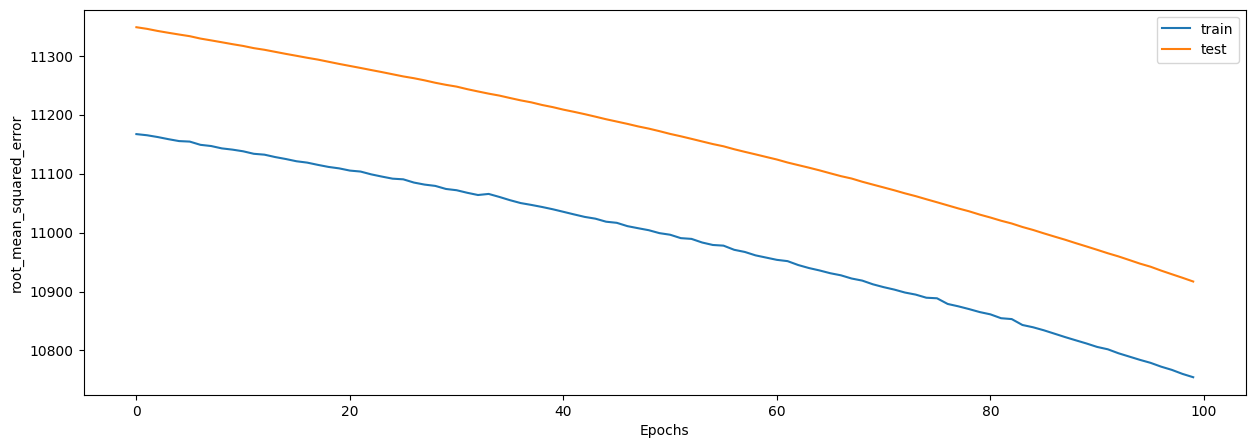

In [64]:
# Plot the model performance 
plt.figure(figsize=(15,5))
plt.plot(history.history['root_mean_squared_error'], label='train')
plt.plot(history.history['val_root_mean_squared_error'], label='test')
plt.xlabel('Epochs')
plt.ylabel('root_mean_squared_error')
plt.legend()
plt.show()